In [ ]:
import kagglehub
# Set the path to the file you'd like to load
file_path = kagglehub.dataset_download("elemento/nyc-yellow-taxi-trip-data")

print("Path to dataset files:", file_path)

Using Colab cache for faster access to the 'nyc-yellow-taxi-trip-data' dataset.
Path to dataset files: /kaggle/input/nyc-yellow-taxi-trip-data


In [ ]:
# Por el tamaño del dataset, se va a tardar
from pyspark.sql import SparkSession
from pyspark.sql.functions import col
from pyspark.sql.types import ByteType, ShortType

spark = SparkSession.builder \
    .appName("nyc_taxi_eda") \
    .config("spark.sql.session.timeZone", "UTC") \
    .getOrCreate()

# Spark infiere el schema y lee los 4 CSVs en un solo paso
df = spark.read.csv(
    file_path + "/*.csv",
    header=True,
    inferSchema=True,
    timestampFormat="yyyy-MM-dd HH:mm:ss"
)

print(f"Filas totales: {df.count():,}")
df.printSchema()

df.show(5)


Filas totales: 47,248,845
root
 |-- VendorID: string (nullable = true)
 |-- tpep_pickup_datetime: string (nullable = true)
 |-- tpep_dropoff_datetime: string (nullable = true)
 |-- passenger_count: string (nullable = true)
 |-- trip_distance: string (nullable = true)
 |-- pickup_longitude: string (nullable = true)
 |-- pickup_latitude: string (nullable = true)
 |-- RateCodeID: string (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- dropoff_longitude: string (nullable = true)
 |-- dropoff_latitude: string (nullable = true)
 |-- payment_type: string (nullable = true)
 |-- fare_amount: string (nullable = true)
 |-- extra: string (nullable = true)
 |-- mta_tax: string (nullable = true)
 |-- tip_amount: string (nullable = true)
 |-- tolls_amount: string (nullable = true)
 |-- improvement_surcharge: string (nullable = true)
 |-- total_amount: string (nullable = true)

+--------+--------------------+---------------------+---------------+-------------+------------------

In [ ]:
from pyspark.sql.functions import col

# Convert column types
df_typed = df.withColumn("VendorID", col("VendorID").cast("int")) \
             .withColumn("tpep_pickup_datetime", col("tpep_pickup_datetime").cast("timestamp")) \
             .withColumn("tpep_dropoff_datetime", col("tpep_dropoff_datetime").cast("timestamp")) \
             .withColumn("passenger_count", col("passenger_count").cast("int")) \
             .withColumn("trip_distance", col("trip_distance").cast("float")) \
             .withColumn("pickup_longitude", col("pickup_longitude").cast("float")) \
             .withColumn("pickup_latitude", col("pickup_latitude").cast("float")) \
             .withColumn("RateCodeID", col("RateCodeID").cast("int")) \
             .withColumn("store_and_fwd_flag", col("store_and_fwd_flag").cast("boolean")) \
             .withColumn("dropoff_longitude", col("dropoff_longitude").cast("float")) \
             .withColumn("dropoff_latitude", col("dropoff_latitude").cast("float")) \
             .withColumn("payment_type", col("payment_type").cast("int")) \
             .withColumn("fare_amount", col("fare_amount").cast("float")) \
             .withColumn("extra", col("extra").cast("float")) \
             .withColumn("mta_tax", col("mta_tax").cast("float")) \
             .withColumn("tip_amount", col("tip_amount").cast("float")) \
             .withColumn("tolls_amount", col("tolls_amount").cast("float")) \
             .withColumn("improvement_surcharge", col("improvement_surcharge").cast("float")) \
             .withColumn("total_amount", col("total_amount").cast("float"))

# Overwrite the original DataFrame with the typed one
df = df_typed

print("Schema después de la conversión de tipos:")
df.printSchema()

df.show(5)

Schema después de la conversión de tipos:
root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp (nullable = true)
 |-- tpep_dropoff_datetime: timestamp (nullable = true)
 |-- passenger_count: integer (nullable = true)
 |-- trip_distance: float (nullable = true)
 |-- pickup_longitude: float (nullable = true)
 |-- pickup_latitude: float (nullable = true)
 |-- RateCodeID: integer (nullable = true)
 |-- store_and_fwd_flag: boolean (nullable = true)
 |-- dropoff_longitude: float (nullable = true)
 |-- dropoff_latitude: float (nullable = true)
 |-- payment_type: integer (nullable = true)
 |-- fare_amount: float (nullable = true)
 |-- extra: float (nullable = true)
 |-- mta_tax: float (nullable = true)
 |-- tip_amount: float (nullable = true)
 |-- tolls_amount: float (nullable = true)
 |-- improvement_surcharge: float (nullable = true)
 |-- total_amount: float (nullable = true)

+--------+--------------------+---------------------+---------------+-------------+---

In [ ]:
from pyspark.sql.functions import col, mean, stddev, count, lit
from pyspark.sql.types import IntegerType, FloatType, DoubleType, LongType

# Identificar columnas numéricas
numerical_cols = [f.name for f in df.schema.fields if isinstance(f.dataType, (IntegerType, FloatType, DoubleType, LongType))]

# --- Calcular Media y Desviación Estándar ---
print("Calculando media y desviación estándar para columnas numéricas...")

# Usar una agregación para calcular media y desviación estándar para todas las columnas numéricas en una sola pasada
agg_exprs = [
    mean(col(c)).alias(f"mean_{c}") for c in numerical_cols
] + [
    stddev(col(c)).alias(f"stddev_{c}") for c in numerical_cols
]

# Recopilar los resultados como una sola fila
stats_row = df.agg(*agg_exprs).collect()[0]

print("\n--- Estadística descriptiva (Media y Desviación Estándar) ---")
print("Columna                | Media        | Desviación Estándar")
print("----------------------------------------------------------")
for col_name in numerical_cols:
    mean_val = stats_row[f"mean_{col_name}"]
    stddev_val = stats_row[f"stddev_{col_name}"]
    print(f"{col_name:22} | {mean_val:12.2f} | {stddev_val:19.2f}")

# --- Calcular Mediana ---
print("\nCalculando mediana para columnas numéricas (puede tardar para grandes datasets, usa approxQuantile)...")
median_results = {}
for col_name in numerical_cols:
    try:
        # approxQuantile devuelve un array, por lo que tomamos el primer elemento (el cuantil 0.5)
        # El tercer argumento (relativeError) controla la precisión frente al rendimiento. 0.01 es un buen equilibrio.
        median_val = df.approxQuantile(col_name, [0.5], 0.01)[0]
        median_results[col_name] = median_val
    except Exception as e:
        median_results[col_name] = f"Error al calcular mediana: {e}"

print("\n--- Mediana ---")
for col_name, value in median_results.items():
    if isinstance(value, float):
        print(f"  {col_name}: {value:.2f}")
    else:
        print(f"  {col_name}: {value}")

# --- Calcular Moda para todas las columnas ---
# Nota: Calcular la moda para cada columna puede ser muy intensivo en recursos para grandes datasets.
# Para datos numéricos continuos, la moda podría no ser muy informativa si muchos valores son únicos.
print("\nCalculando moda para todas las columnas (puede tardar y ser muy intensivo en recursos para cada columna):")
print("Considera que para columnas con muchos valores únicos, la moda podría no ser muy útil o tardar mucho. Se tomará el valor más frecuente.")

mode_results = {}
for col_name in df.columns:
    try:
        # Agrupar por la columna, contar ocurrencias, ordenar por conteo descendente y tomar el primer valor
        # Esto encuentra el valor más frecuente (moda)
        mode_value_row = df.groupBy(col_name).count().orderBy(col("count").desc()).limit(1).collect()
        if mode_value_row:
            mode_results[col_name] = mode_value_row[0][col_name]
        else:
            mode_results[col_name] = "N/A (columna vacía o solo nulos)"
    except Exception as e:
        mode_results[col_name] = f"Error al calcular moda: {e}"

print("\n--- Moda ---")
for col_name, value in mode_results.items():
    print(f"  {col_name}: {value}")

Calculando media y desviación estándar para columnas numéricas...

--- Estadística descriptiva (Media y Desviación Estándar) ---
Columna                | Media        | Desviación Estándar
----------------------------------------------------------
VendorID               |         1.53 |                0.50
passenger_count        |         1.67 |                1.32
trip_distance          |         7.51 |             6487.66
pickup_longitude       |       -72.76 |                9.38
pickup_latitude        |        40.08 |                5.17
RateCodeID             |         1.04 |                0.59
dropoff_longitude      |       -72.83 |                9.15
dropoff_latitude       |        40.12 |                5.04
payment_type           |         1.35 |                0.49
fare_amount            |        12.39 |               78.62
extra                  |         0.32 |                0.52
mta_tax                |         0.50 |                0.05
tip_amount             |        

In [ ]:
from pyspark.sql.functions import col, sum

# Calculate null counts for each column
null_counts = df.select([sum(col(c).isNull().cast("int")).alias(c) for c in df.columns])

# Display the results
print("Conteo de valores nulos por columna:")
null_counts.show(truncate=False)

Conteo de valores nulos por columna:
+--------+--------------------+---------------------+---------------+-------------+----------------+---------------+----------+------------------+-----------------+----------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|pickup_longitude|pickup_latitude|RateCodeID|store_and_fwd_flag|dropoff_longitude|dropoff_latitude|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|
+--------+--------------------+---------------------+---------------+-------------+----------------+---------------+----------+------------------+-----------------+----------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+
|0       |0                   |0                    |0              |0            |0               |0              |0      

In [ ]:
df.show(5)


+--------+--------------------+---------------------+---------------+-------------+----------------+---------------+----------+------------------+-----------------+----------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|pickup_longitude|pickup_latitude|RateCodeID|store_and_fwd_flag|dropoff_longitude|dropoff_latitude|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|
+--------+--------------------+---------------------+---------------+-------------+----------------+---------------+----------+------------------+-----------------+----------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+
|       2| 2015-01-15 19:05:39|  2015-01-15 19:23:42|              1|         1.59|        -73.9939|       40.75011|         1|             false|       -73.974

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Definir las columnas para graficar por categoría
plot_cols_lon = ["pickup_longitude", "dropoff_longitude"]
plot_cols_lat = ["pickup_latitude", "dropoff_latitude"]
plot_cols_dist = ["trip_distance"]
plot_cols_amount = ["fare_amount", "tip_amount", "total_amount"] # Columnas representativas de 'amount'

# Combinar todas las columnas para seleccionar del DataFrame de Spark
all_plot_cols = plot_cols_lon + plot_cols_lat + plot_cols_dist + plot_cols_amount

print("Preparando los datos para los boxplots. Esto puede tomar un tiempo y consumir mucha memoria para datasets muy grandes.")
print("Si el proceso falla o es muy lento, considera muestrear el DataFrame antes de convertirlo a Pandas (ej: df.sample(False, 0.01).select(...).toPandas()).")

try:
    # Convertir las columnas seleccionadas a un DataFrame de Pandas para graficar
    df_plot_pandas = df.select(all_plot_cols).toPandas()

    # Crear los boxplots
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle('Boxplots de Variables Numéricas Clave', fontsize=16)

    # Boxplot de Longitudes
    sns.boxplot(data=df_plot_pandas[plot_cols_lon], ax=axes[0, 0], orient="h")
    axes[0, 0].set_title('Longitudes de Recogida y Destino')
    axes[0, 0].set_xlabel('Longitud')

    # Boxplot de Latitudes
    sns.boxplot(data=df_plot_pandas[plot_cols_lat], ax=axes[0, 1], orient="h")
    axes[0, 1].set_title('Latitudes de Recogida y Destino')
    axes[0, 1].set_xlabel('Latitud')

    # Boxplot de Distancia del Viaje
    sns.boxplot(data=df_plot_pandas[plot_cols_dist], ax=axes[1, 0], orient="h")
    axes[1, 0].set_title('Distancia del Viaje')
    axes[1, 0].set_xlabel('Distancia (millas)')

    # Boxplot de Valores de Monto
    sns.boxplot(data=df_plot_pandas[plot_cols_amount], ax=axes[1, 1], orient="h")
    axes[1, 1].set_title('Valores de Monto (Tarifa, Propina, Total)')
    axes[1, 1].set_xlabel('Monto ($)')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajustar layout para el título principal
    plt.show()

except Exception as e:
    print(f"Ocurrió un error al generar los boxplots: {e}")
    print("Probablemente, el dataset es demasiado grande para ser convertido a Pandas directamente en la memoria del driver.")
    print("Para solucionar esto, puedes muestrear los datos antes de graficar. Por ejemplo:")
    print("df_plot_pandas = df.sample(False, 0.001, seed=42).select(all_plot_cols).toPandas()")
    print("Intenta ajustar el factor de muestreo (0.001 en este ejemplo) según sea necesario.")

Preparando los datos para los boxplots. Esto puede tomar un tiempo y consumir mucha memoria para datasets muy grandes.
Si el proceso falla o es muy lento, considera muestrear el DataFrame antes de convertirlo a Pandas (ej: df.sample(False, 0.01).select(...).toPandas()).
Ocurrió un error al generar los boxplots: An error occurred while calling o930.collectToPython.
: org.apache.spark.SparkException: Job aborted due to stage failure: Task 15 in stage 103.0 failed 1 times, most recent failure: Lost task 15.0 in stage 103.0 (TID 2347) (e8ec47c39677 executor driver): TaskResultLost (result lost from block manager)
Driver stacktrace:
	at org.apache.spark.scheduler.DAGScheduler.$anonfun$abortStage$3(DAGScheduler.scala:2935)
	at scala.Option.getOrElse(Option.scala:201)
	at org.apache.spark.scheduler.DAGScheduler.$anonfun$abortStage$2(DAGScheduler.scala:2935)
	at org.apache.spark.scheduler.DAGScheduler.$anonfun$abortStage$2$adapted(DAGScheduler.scala:2927)
	at scala.collection.immutable.List.fo

In [ ]:
from pyspark.sql.functions import col, unix_timestamp, hour, dayofweek, month, year, to_date

# Variable derivada: duración del viaje en minutos
df = df.withColumn(
    "trip_duration_min",
    (unix_timestamp("tpep_dropoff_datetime") - unix_timestamp("tpep_pickup_datetime")) / 60.0
)

# Variables temporales derivadas (útiles para gráficas de patrones)
df = df.withColumn("pickup_hour", hour("tpep_pickup_datetime")) \
       .withColumn("pickup_dayofweek", dayofweek("tpep_pickup_datetime")) \
       .withColumn("pickup_month", month("tpep_pickup_datetime")) \
       .withColumn("pickup_year", year("tpep_pickup_datetime"))

# Muestra del 1% para gráficas (≈470K filas, manejable en pandas)
df_sample = df.sample(False, 0.01, seed=42).cache()
print(f"Tamaño de la muestra: {df_sample.count():,} filas")

df.printSchema()

Tamaño de la muestra: 472,861 filas
root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp (nullable = true)
 |-- tpep_dropoff_datetime: timestamp (nullable = true)
 |-- passenger_count: integer (nullable = true)
 |-- trip_distance: float (nullable = true)
 |-- pickup_longitude: float (nullable = true)
 |-- pickup_latitude: float (nullable = true)
 |-- RateCodeID: integer (nullable = true)
 |-- store_and_fwd_flag: boolean (nullable = true)
 |-- dropoff_longitude: float (nullable = true)
 |-- dropoff_latitude: float (nullable = true)
 |-- payment_type: integer (nullable = true)
 |-- fare_amount: float (nullable = true)
 |-- extra: float (nullable = true)
 |-- mta_tax: float (nullable = true)
 |-- tip_amount: float (nullable = true)
 |-- tolls_amount: float (nullable = true)
 |-- improvement_surcharge: float (nullable = true)
 |-- total_amount: float (nullable = true)
 |-- trip_duration_min: double (nullable = true)
 |-- pickup_hour: integer (nullable = true)


In [ ]:
from pyspark.sql.functions import col, count, when

total = df.count()

# Conteo de registros problemáticos por categoría
problemas = df.select(
    count(when(col("fare_amount") <= 0, True)).alias("fare_amount <= 0"),
    count(when(col("total_amount") <= 0, True)).alias("total_amount <= 0"),
    count(when(col("trip_distance") <= 0, True)).alias("trip_distance <= 0"),
    count(when(col("trip_distance") > 100, True)).alias("trip_distance > 100 millas"),
    count(when(col("passenger_count") == 0, True)).alias("passenger_count == 0"),
    count(when(col("passenger_count") > 6, True)).alias("passenger_count > 6"),
    count(when((col("pickup_longitude") == 0) | (col("pickup_latitude") == 0), True)).alias("coords pickup en (0,0)"),
    count(when((col("dropoff_longitude") == 0) | (col("dropoff_latitude") == 0), True)).alias("coords dropoff en (0,0)"),
    count(when(
        (col("pickup_latitude") < 40.5) | (col("pickup_latitude") > 41.0) |
        (col("pickup_longitude") < -74.3) | (col("pickup_longitude") > -73.7), True
    )).alias("pickup fuera bbox NYC"),
    count(when(col("trip_duration_min") <= 0, True)).alias("duracion <= 0"),
    count(when(col("trip_duration_min") > 360, True)).alias("duracion > 6 horas"),
    count(when(col("tpep_dropoff_datetime") <= col("tpep_pickup_datetime"), True)).alias("dropoff <= pickup"),
).collect()[0]

print(f"Total de registros: {total:,}\n")
print(f"{'Problema':<35} | {'Conteo':>12} | {'% del total':>10}")
print("-" * 65)
for nombre in problemas.asDict():
    n = problemas[nombre]
    pct = (n / total) * 100
    print(f"{nombre:<35} | {n:>12,} | {pct:>9.4f}%")

Total de registros: 47,248,845

Problema                            |       Conteo | % del total
-----------------------------------------------------------------
fare_amount <= 0                    |       31,044 |    0.0657%
total_amount <= 0                   |       21,496 |    0.0455%
trip_distance <= 0                  |      282,241 |    0.5974%
trip_distance > 100 millas          |          457 |    0.0010%
passenger_count == 0                |        8,214 |    0.0174%
passenger_count > 6                 |          227 |    0.0005%
coords pickup en (0,0)              |      772,525 |    1.6350%
coords dropoff en (0,0)             |      733,833 |    1.5531%
pickup fuera bbox NYC               |      779,907 |    1.6506%
duracion <= 0                       |       51,380 |    0.1087%
duracion > 6 horas                  |       61,198 |    0.1295%
dropoff <= pickup                   |       51,380 |    0.1087%


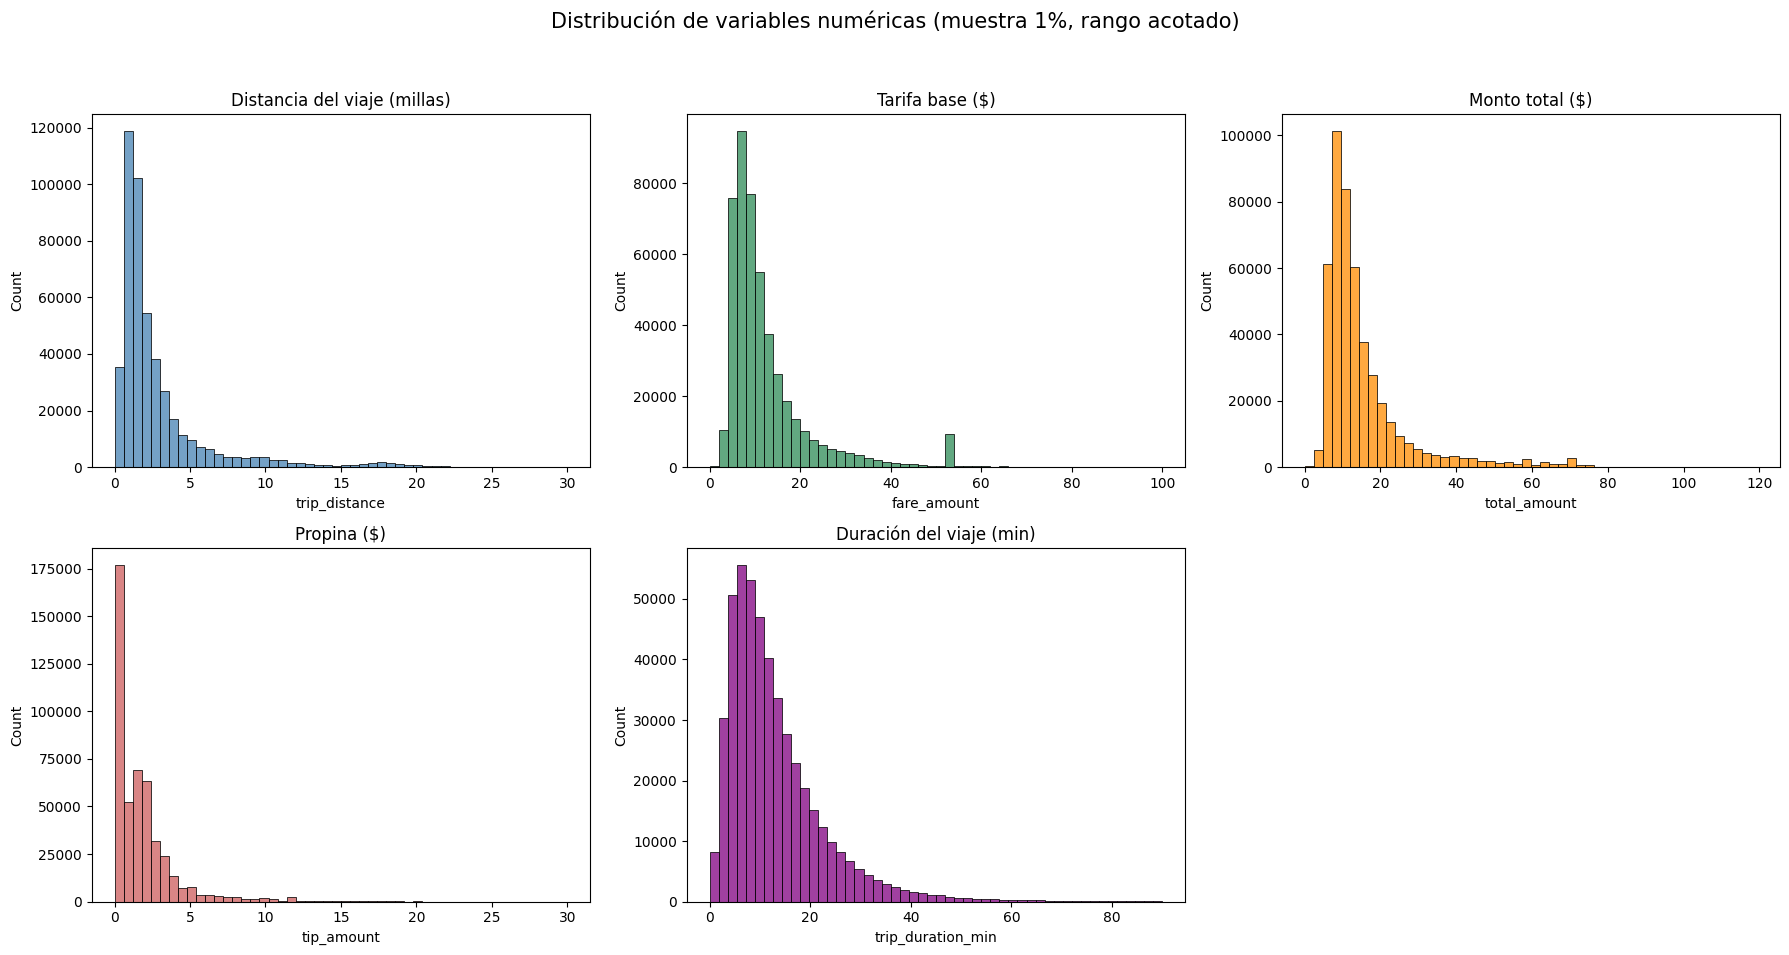

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Traer muestra a pandas, filtrando rangos razonables solo para visualizar
pdf = df_sample.select(
    "trip_distance", "fare_amount", "total_amount", "tip_amount", "trip_duration_min"
).toPandas()

# Recortar para que las gráficas sean legibles (no cambia los datos, solo el rango visual)
pdf_viz = pdf[
    (pdf["trip_distance"].between(0, 30)) &
    (pdf["fare_amount"].between(0, 100)) &
    (pdf["total_amount"].between(0, 120)) &
    (pdf["tip_amount"].between(0, 30)) &
    (pdf["trip_duration_min"].between(0, 90))
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Distribución de variables numéricas (muestra 1%, rango acotado)", fontsize=15)

sns.histplot(pdf_viz["trip_distance"], bins=50, ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title("Distancia del viaje (millas)")

sns.histplot(pdf_viz["fare_amount"], bins=50, ax=axes[0, 1], color="seagreen")
axes[0, 1].set_title("Tarifa base ($)")

sns.histplot(pdf_viz["total_amount"], bins=50, ax=axes[0, 2], color="darkorange")
axes[0, 2].set_title("Monto total ($)")

sns.histplot(pdf_viz["tip_amount"], bins=50, ax=axes[1, 0], color="indianred")
axes[1, 0].set_title("Propina ($)")

sns.histplot(pdf_viz["trip_duration_min"], bins=50, ax=axes[1, 1], color="purple")
axes[1, 1].set_title("Duración del viaje (min)")

axes[1, 2].axis("off")  # espacio vacío

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

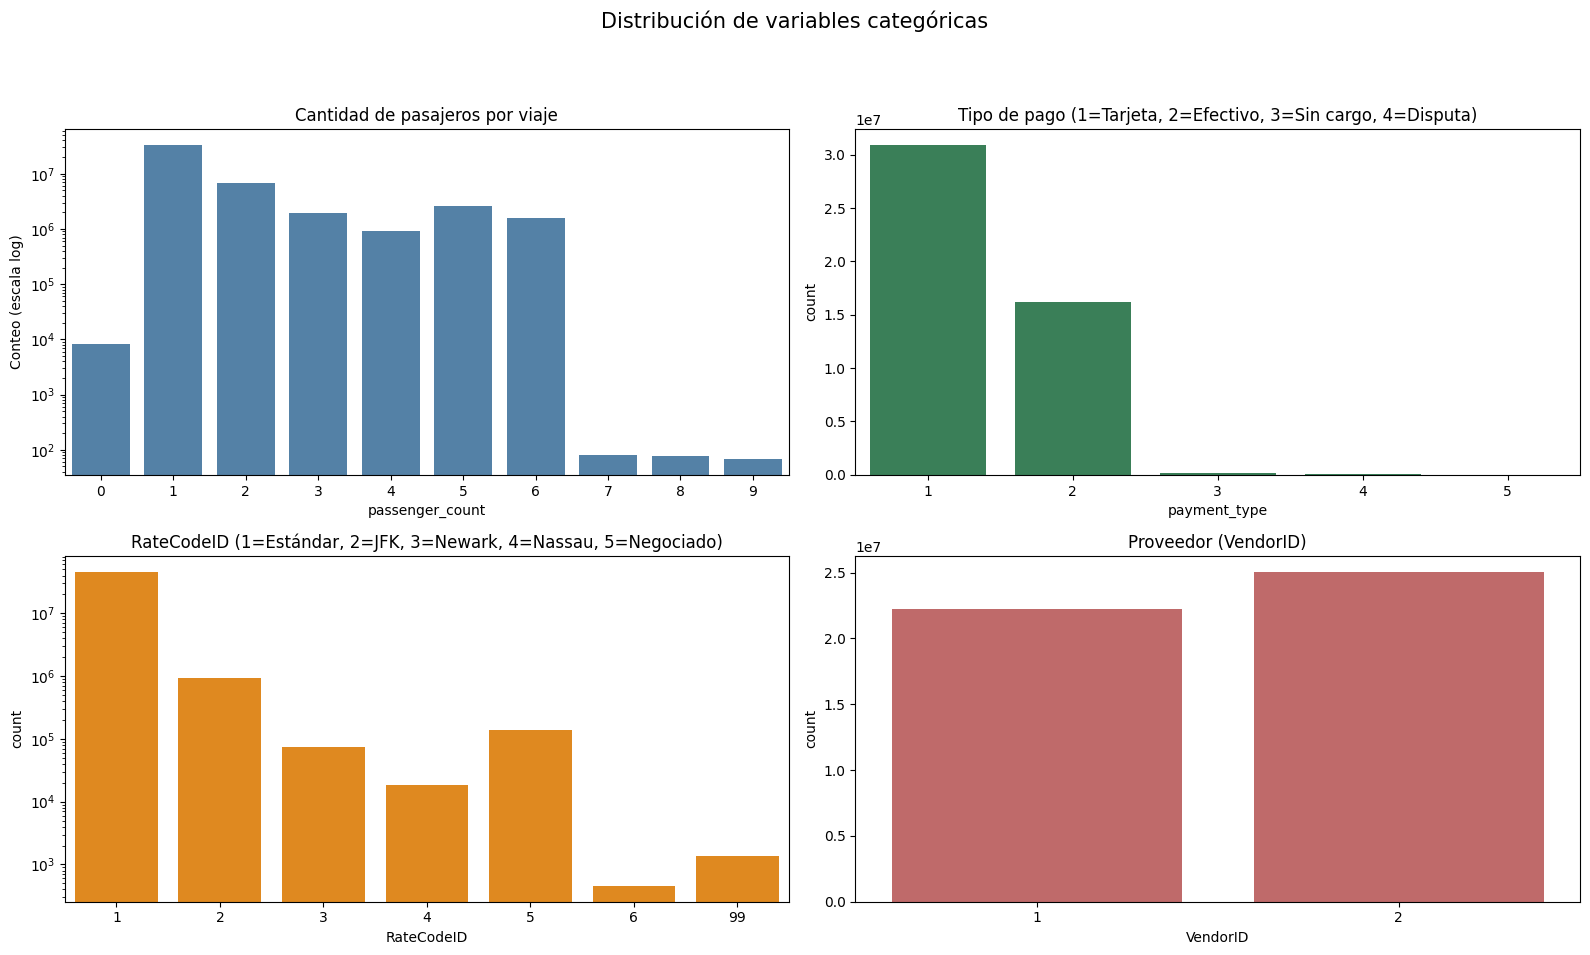

In [ ]:
from pyspark.sql.functions import col

# Conteos directos en Spark (eficiente, no requiere muestra)
def conteo_categoria(col_name):
    return df.groupBy(col_name).count().orderBy(col_name).toPandas()

passenger_df = conteo_categoria("passenger_count")
payment_df   = conteo_categoria("payment_type")
ratecode_df  = conteo_categoria("RateCodeID")
vendor_df    = conteo_categoria("VendorID")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Distribución de variables categóricas", fontsize=15)

sns.barplot(data=passenger_df, x="passenger_count", y="count", ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title("Cantidad de pasajeros por viaje")
axes[0, 0].set_yscale("log")
axes[0, 0].set_ylabel("Conteo (escala log)")

sns.barplot(data=payment_df, x="payment_type", y="count", ax=axes[0, 1], color="seagreen")
axes[0, 1].set_title("Tipo de pago (1=Tarjeta, 2=Efectivo, 3=Sin cargo, 4=Disputa)")

sns.barplot(data=ratecode_df, x="RateCodeID", y="count", ax=axes[1, 0], color="darkorange")
axes[1, 0].set_title("RateCodeID (1=Estándar, 2=JFK, 3=Newark, 4=Nassau, 5=Negociado)")
axes[1, 0].set_yscale("log")

sns.barplot(data=vendor_df, x="VendorID", y="count", ax=axes[1, 1], color="indianred")
axes[1, 1].set_title("Proveedor (VendorID)")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

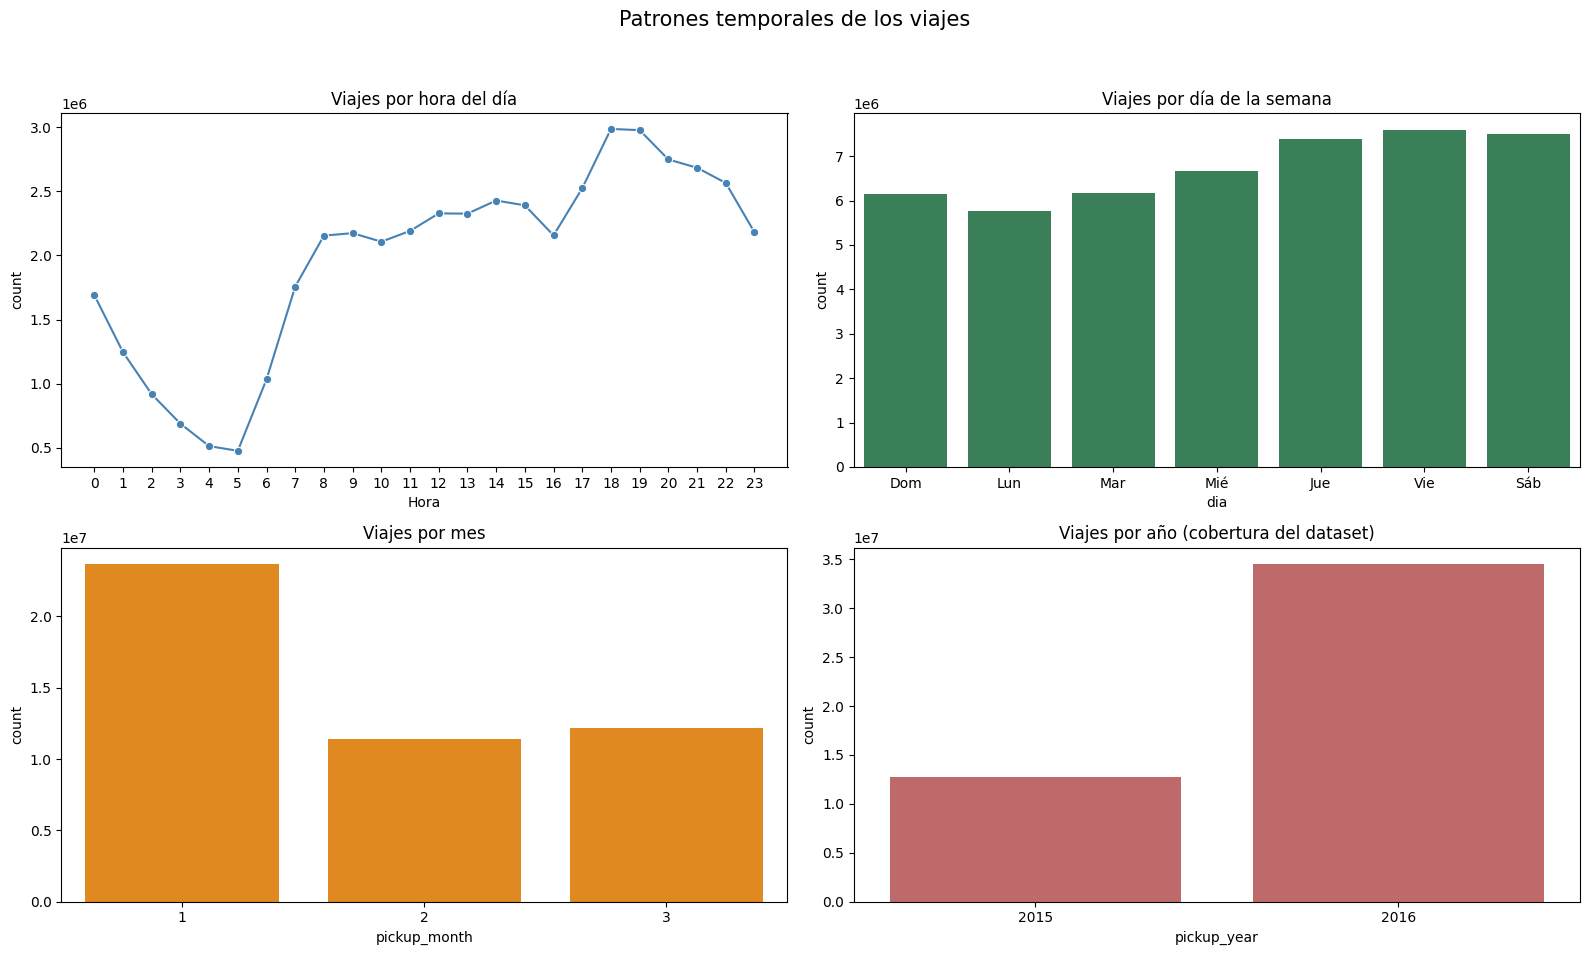

In [ ]:
# Agregaciones en Spark, traer pequeño a pandas
hora_df = df.groupBy("pickup_hour").count().orderBy("pickup_hour").toPandas()
dow_df  = df.groupBy("pickup_dayofweek").count().orderBy("pickup_dayofweek").toPandas()
mes_df  = df.groupBy("pickup_month").count().orderBy("pickup_month").toPandas()
anio_df = df.groupBy("pickup_year").count().orderBy("pickup_year").toPandas()

# Mapear día de semana (1=domingo en Spark)
dias = {1: "Dom", 2: "Lun", 3: "Mar", 4: "Mié", 5: "Jue", 6: "Vie", 7: "Sáb"}
dow_df["dia"] = dow_df["pickup_dayofweek"].map(dias)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Patrones temporales de los viajes", fontsize=15)

sns.lineplot(data=hora_df, x="pickup_hour", y="count", ax=axes[0, 0], marker="o", color="steelblue")
axes[0, 0].set_title("Viajes por hora del día")
axes[0, 0].set_xticks(range(0, 24))
axes[0, 0].set_xlabel("Hora")

sns.barplot(data=dow_df, x="dia", y="count", ax=axes[0, 1], color="seagreen")
axes[0, 1].set_title("Viajes por día de la semana")

sns.barplot(data=mes_df, x="pickup_month", y="count", ax=axes[1, 0], color="darkorange")
axes[1, 0].set_title("Viajes por mes")

sns.barplot(data=anio_df, x="pickup_year", y="count", ax=axes[1, 1], color="indianred")
axes[1, 1].set_title("Viajes por año (cobertura del dataset)")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

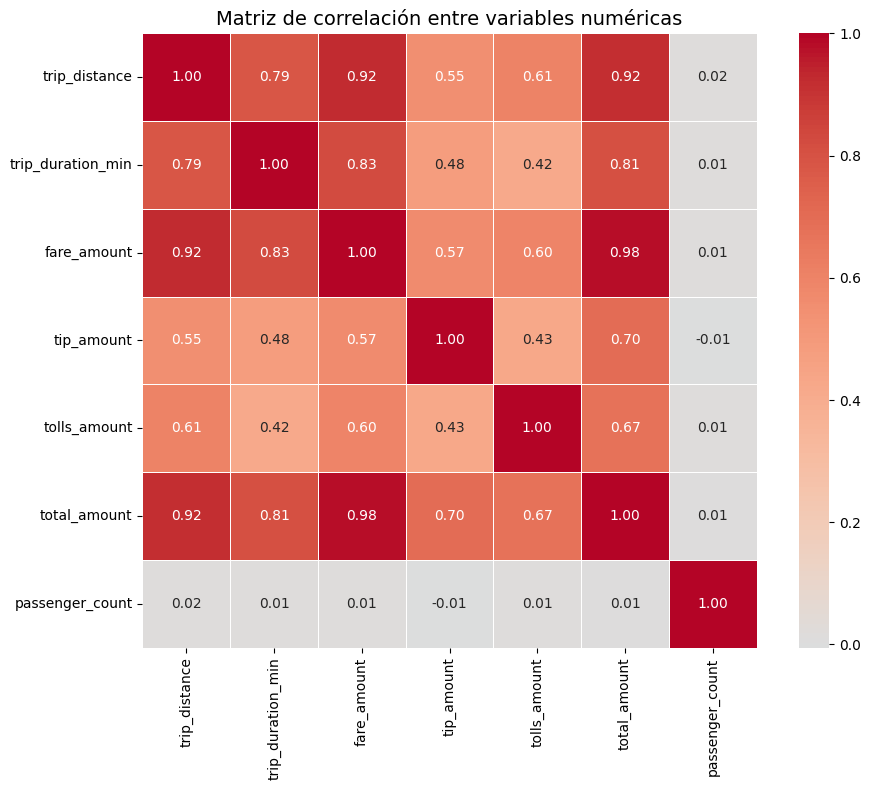

In [ ]:
import numpy as np

# Tomar muestra ya filtrada para correlación (sin outliers extremos que distorsionan)
pdf_corr = df_sample.select(
    "trip_distance", "trip_duration_min", "fare_amount", "tip_amount",
    "tolls_amount", "total_amount", "passenger_count"
).toPandas()

# Filtrar valores razonables
pdf_corr = pdf_corr[
    (pdf_corr["trip_distance"].between(0, 50)) &
    (pdf_corr["trip_duration_min"].between(0, 180)) &
    (pdf_corr["fare_amount"].between(0, 200)) &
    (pdf_corr["total_amount"].between(0, 250))
]

corr = pdf_corr.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, linewidths=0.5)
plt.title("Matriz de correlación entre variables numéricas", fontsize=14)
plt.tight_layout()
plt.show()

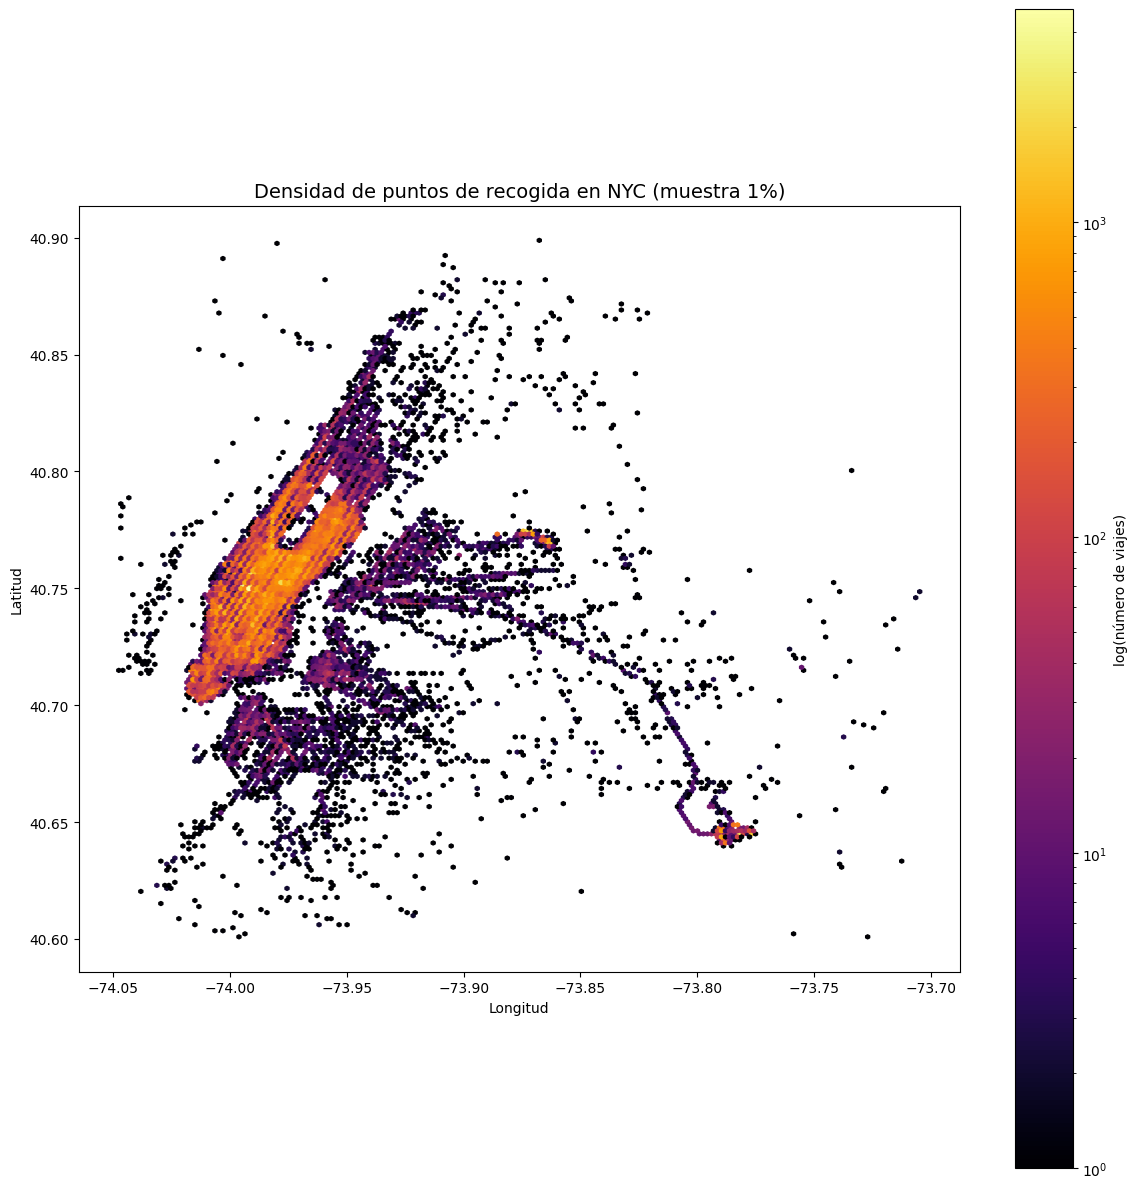

In [ ]:
# Filtrar a bounding box de NYC y traer muestra a pandas
pdf_geo = df_sample.select("pickup_longitude", "pickup_latitude").toPandas()
pdf_geo = pdf_geo[
    (pdf_geo["pickup_latitude"].between(40.6, 40.9)) &
    (pdf_geo["pickup_longitude"].between(-74.05, -73.7))
]

plt.figure(figsize=(12, 12))
plt.hexbin(
    pdf_geo["pickup_longitude"], pdf_geo["pickup_latitude"],
    gridsize=200, cmap="inferno", bins="log", mincnt=1
)
plt.colorbar(label="log(número de viajes)")
plt.title("Densidad de puntos de recogida en NYC (muestra 1%)", fontsize=14)
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.gca().set_aspect("equal")
plt.tight_layout()
plt.show()

## Pre-procesamiento propuesto

Con base en el análisis exploratorio, el dataset requiere las siguientes etapas de corrección antes de cualquier modelado:

### 1. Valores nulos
- `improvement_surcharge`: 3 registros nulos. Imputar con la moda (0.3) o eliminar (impacto despreciable).

### 2. Outliers en variables monetarias
- `fare_amount`, `total_amount`: descartar registros con valores ≤ 0 (errores de captura o reembolsos).
- Aplicar tope superior por regla IQR o percentil 99 para evitar que tarifas extremas distorsionen modelos.
- `tip_amount`: la desviación estándar de 574.74 evidencia outliers severos; aplicar tope por percentil 99.

### 3. Outliers en distancia y duración
- `trip_distance`: descartar valores ≤ 0 y > 100 millas (NYC no permite viajes tan largos en taxi amarillo).
- `trip_duration_min`: descartar duraciones ≤ 0 y > 360 minutos (6 horas como cota razonable).
- Descartar registros donde `dropoff_datetime ≤ pickup_datetime`.

### 4. Coordenadas geográficas inválidas
- Eliminar registros con coordenadas en (0, 0).
- Filtrar al bounding box de NYC: latitud [40.5, 41.0], longitud [-74.3, -73.7].

### 5. Inconsistencias en pasajeros
- `passenger_count == 0`: descartar (un viaje sin pasajeros no es válido).
- `passenger_count > 6`: revisar; el límite legal de un Yellow Taxi es 5–6 pasajeros.

### 6. Tipos de datos
- Conversión ya aplicada: timestamps, enteros y flotantes correctamente tipados.

### 7. Variables categóricas
- `VendorID`, `RateCodeID`, `payment_type`, `store_and_fwd_flag`: mantener como categóricas codificadas. Documentar el catálogo según el TLC Data Dictionary para interpretación correcta.

### 8. Variables derivadas a generar para el análisis
- `trip_duration_min` (ya creada).
- `pickup_hour`, `pickup_dayofweek`, `pickup_month`, `pickup_year` (ya creadas).
- Velocidad promedio (`trip_distance / trip_duration_min * 60`) — útil para detectar outliers adicionales.
- Tip ratio (`tip_amount / fare_amount`) — para análisis de comportamiento de propina.